# Pattern Recognition, removal of rows, and formatting of data 

In [32]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
# Set pandas options to avoid truncation of rows and columns
pd.set_option('display.max_rows', None)       # Show all rows
pd.set_option('display.max_columns', None)    # Show all columns
pd.set_option('display.width', None)          # Adjust the display width dynamically
pd.set_option('display.max_colwidth', None)   # Prevent truncation of cell content

In [33]:
# import data
file_path = 'results-survey134246.csv'

df = pd.read_csv(file_path)

df.columns

Index(['id', 'submitdate', 'lastpage', 'startlanguage', 'seed', 'refurl',
       'G01Q18', 'proceed', 'G01Q01[SQ001]', 'G01Q01[SQ002]',
       ...
       'G05Q16Time', 'groupTime1716', 'G04Q14Time', 'G01Q15Time',
       'groupTime1720', 'G05Q22Time', 'groupTime1718', 'G06Q17Time',
       'G07Q20Time', 'G01Q21Time'],
      dtype='object', length=130)

In [34]:
# drop columns that are not needed
dropping = ['interviewtime', 'groupTime1719', 'G01Q18Time', 'proceedTime', 'groupTime1713',
       'G01Q01Time', 'G01Q02Time', 'G01Q03Time', 'G01Q04Time', 'G01Q05Time',
       'G02Q07Time', 'startlanguage', 'seed', 'proceed', 'submitdate', 'lastpage', 'refurl', 'G01Q18', 'G05Q16Time', 'groupTime1716', 'G04Q14Time', 'G01Q15Time', 'groupTime1720', 'G05Q22Time', 'groupTime1718', 'G06Q17Time', 'G07Q20Time', 'G01Q21Time', 'G01Q06Time', 'groupTime1714', 'G01Q08Time', 'G02Q09Time', 'G02Q10Time', 'groupTime1715', 'G03Q11Time', 'G03Q12Time', 'G03Q13Time']
df = df.drop(dropping, axis=1)



In [35]:
df.columns

Index(['id', 'G01Q01[SQ001]', 'G01Q01[SQ002]', 'G01Q01[SQ003]', 'G01Q02',
       'G01Q03[SQ001]', 'G01Q03[SQ002]', 'G01Q03[SQ005]', 'G01Q03[SQ003]',
       'G01Q03[SQ004]', 'G01Q03[SQ006]', 'G01Q04', 'G01Q05', 'G01Q06',
       'G02Q07', 'G01Q08[SQ001]', 'G01Q08[SQ002]', 'G01Q08[SQ003]',
       'G01Q08[other]', 'G02Q09[SQ001]', 'G02Q09[SQ002]', 'G02Q09[SQ003]',
       'G02Q09[SQ004]', 'G02Q09[SQ005]', 'G02Q09[SQ009]', 'G02Q09[SQ006]',
       'G02Q09[SQ007]', 'G02Q09[SQ008]', 'G02Q09[other]', 'G02Q10[SQ001]',
       'G02Q10[SQ002]', 'G02Q10[SQ003]', 'G02Q10[SQ004]', 'G02Q10[SQ005]',
       'G02Q10[SQ008]', 'G02Q10[SQ006]', 'G02Q10[SQ007]', 'G03Q11[SQ001]',
       'G03Q11[SQ002]', 'G03Q11[SQ003]', 'G03Q11[SQ004]', 'G03Q11[other]',
       'G03Q12[SQ001]', 'G03Q12[SQ002]', 'G03Q12[SQ003]', 'G03Q12[SQ004]',
       'G03Q13[SQ001]', 'G03Q13[SQ002]', 'G03Q13[SQ003]', 'G05Q16[SQ001]',
       'G05Q16[SQ002]', 'G05Q16[SQ007]', 'G05Q16[SQ008]', 'G05Q16[SQ003]',
       'G05Q16[SQ004]', 'G05Q16[SQ005

Rename columns from Survey Codes for readability

In [36]:
df.rename(columns={'G01Q01[SQ001]': 'PC', 'G01Q01[SQ002]': 'console', 'G01Q01[SQ003]': 'mobile', 'G01Q02': 'hours', 'G01Q03[SQ001]': 'CS', 'G01Q03[SQ002]': 'DOTA', 'G01Q03[SQ005]': 'FN', 'G01Q03[SQ003]': 'LOL', 'G01Q03[SQ004]': 'VAL', 'G01Q03[SQ006]': 'noGame', 'G01Q04': 'participation', 'G01Q05': 'leftGroup', 'G01Q06': 'gamerIdentity'}, inplace=True)

df['hours'] = df['hours'].replace({'More than 20 hours': '>20', '5 to 10 hours': '5-10', '10 to 20 hours': '10-20', 'Less than 5 hours': '<5'})
df['participation'] = df['participation'].replace({'Active Participant (Posting, Organizing Events, Moderating Communities, ...)': 'Active', 'Passive Participant (Reading posts, Attending Events, ...)': 'Passive', 'Not involved ("just" playing)': 'Not'})
df['gamerIdentity'] = df['gamerIdentity'].replace({'Yes, I strongly identify as a gamer.': 'Strongly', 'Somewhat, I identify as a gamer in certain contexts.': 'Somewhat', "No, I don't identify as a gamer, even though I play games.": 'Not'})


# rename severity questions 
df.rename(columns={'G02Q07': 'revealGender', 'G01Q08[SQ001]': 'ingameTeamChatFlame', 'G01Q08[SQ002]': 'ingameAllChatFlame', 'G01Q08[SQ003]': 'TeamVoiceChatFlame', 'G01Q08[other]': 'otherFlame'}, inplace=True)
df.rename(columns={'G02Q09[SQ001]': 'trollingThrowingSeverity_lastmonth', 'G02Q09[SQ002]': 'leavingSeverity_lastmonth', 'G02Q09[SQ003]': 'nameCallingSeverity_lastmonth', 'G02Q09[SQ004]': 'sexMesSeverity_lastmonth', 'G02Q09[SQ005]': 'patronizingSeverity_lastmonth', 'G02Q09[SQ006]': 'doxxingSeverity_lastmonth', 'G02Q09[SQ007]': 'microAgressionSeverity_lastmonth', 'G02Q09[SQ009]': 'flirtingSeverity_lastmonth', 'G02Q09[SQ008]': 'noHarassment_lastmonth', 'G02Q09[other]': 'typesOther_lastmonth'}, inplace=True)
df.rename(columns={'G02Q10[SQ001]': 'trollingThrowingSeverity', 'G02Q10[SQ002]': 'leavingSeverity', 'G02Q10[SQ003]': 'nameCallingSeverity', 'G02Q10[SQ004]': 'sexMesSeverity', 'G02Q10[SQ005]': 'patronizingSeverity', 'G02Q10[SQ006]': 'doxxingSeverity', 'G02Q10[SQ007]': 'microAgressionSeverity', 'G02Q10[SQ008]': 'flirtingSeverity'}, inplace=True)

df.rename(columns={'G03Q11[SQ001]': 'userNameChange', 'G03Q11[SQ002]': 'voiceSettingsChange', 'G03Q11[SQ003]': 'profileInfoChange', 'G03Q11[SQ004]': 'noChanges', 'G03Q11[other]': 'changeOtherIdentity'}, inplace=True)
df.rename(columns={'G03Q12[SQ001]': 'senseOfBelonging', 'G03Q12[SQ002]': 'discouraging', 'G03Q12[SQ003]': 'welcomingSpace', 'G03Q12[SQ004]': 'avoidCommunities'}, inplace=True)

df.rename(columns={'G03Q13[SQ001]': 'affectedIngameComms', 'G03Q13[SQ002]': 'affectedJoinComp', 'G03Q13[SQ003]': 'affectedNonComp'}, inplace=True)
df.rename(columns={'G05Q16[SQ001]': 'reportingMe', 'G05Q16[SQ002]': 'reportingOther', 'G05Q16[SQ007]': 'mutingTeamVoice', 'G05Q16[SQ008]': 'mutingTeamText', 'G05Q16[SQ003]': 'mutingVoicePlayer', 'G05Q16[SQ004]': 'mutingTextPlayer', 'G05Q16[SQ005]': 'mutingAllVoice', 'G05Q16[SQ006]': 'mutingAllText',}, inplace=True)

df.rename(columns={'G04Q14[SQ001]': 'upsetsMe', 'G04Q14[SQ002]': 'upsetAfterPlaying', 'G04Q14[SQ003]': 'teamSupportsMe', 'G04Q14[SQ004]': 'notPhased', 'G04Q14[SQ005]': 'teamSaysNothing', 'G04Q14[SQ006]': 'teamAddsSexism'}, inplace=True)

# rename examples questions 
df.rename(columns={
    'G01Q15[SQ001]': 'ex1', 'G01Q15[SQ002]': 'ex2',
    'G01Q15[SQ003]': 'ex3', 'G01Q15[SQ004]': 'ex4',
    'G01Q15[SQ005]': 'ex5', 'G01Q15[SQ006]': 'ex6',  
    'G01Q15[SQ007]': 'ex7', 'G01Q15[SQ008]': 'ex8',
    'G01Q15[SQ009]': 'ex9', 'G01Q15[SQ010]': 'ex10',
}, inplace=True)

df.rename(columns={
    'G05Q22[SQ001]': 'exSev1', 'G05Q22[SQ002]': 'exSev2',
    'G05Q22[SQ003]': 'exSev3', 'G05Q22[SQ004]': 'exSev4',
    'G05Q22[SQ005]': 'exSev5', 'G05Q22[SQ006]': 'exSev6',  
    'G05Q22[SQ007]': 'exSev7', 'G05Q22[SQ008]': 'exSev8',
    'G05Q22[SQ009]': 'exSev9', 'G05Q22[SQ010]': 'exSev10',
}, inplace=True)

# rename demographics questions 
df.rename(columns={'G06Q17' : 'gender', 'G06Q17[other]': 'genderOther', 'G07Q20': 'age', 'G01Q21[SQ001]': 'EU', 'G01Q21[SQ002]': 'ASIA', 'G01Q21[SQ003]': 'SA', 'G01Q21[SQ004]': 'NA', 'G01Q21[SQ005]': 'AFR', 'G01Q21[SQ007]': 'OCE', 'G01Q21[SQ006]': 'ASIA'}, inplace=True)


Replace Answer Strings with numerical values

In [37]:
df.replace({
    # Severity Scale
    '7 (Extremely Severe)': '7',
    '6 (Very Severe)': '6',
    '5 (Severe)': '5',
    '4 (Moderate)': '4',
    '3 (Mild)': '3',
    '2 (Very Mild)': '2',
    '1 (Not Severe at All)': '1',

    # Real / Not Real
    'Real': '1',
    'Not Real': '0',

    # Yes / No
    'Yes': '1',
    'No': '0',

    # Agreement Scale (Optional)
    'Strongly disagree': '1',
    'Disagree': '2',
    'Neutral': '3',
    'Agree': '4',
    'Strongly agree': '5',
    
    # Always-Never Scale
    'Never': '1',
    'Rarely': '2',
    'Sometimes': '3',
    'Often': '4',
    'Always': '5',

    # Age Range (Optional)
    '18 - 25 years old': '18-25',
    'Under 18 years old': '<18',
    '25 - 35 years old': '26-35',
    'Over 35 years old': '>35',
    
    # Gender identity
    'Non-binary': 'NB',
    'Female': 'F',
    'Male': 'M',
    'Agender': 'A',
    'Genderfluid': 'G',
    'Other': 'O',
    
    'Not at all': 1,
    'Slightly': 2,
    'Moderately': 3,
    'Significantly': 4,
    'Completely': 5,
    
}, inplace=True)

In [38]:
df.columns

Index(['id', 'PC', 'console', 'mobile', 'hours', 'CS', 'DOTA', 'FN', 'LOL',
       'VAL', 'noGame', 'participation', 'leftGroup', 'gamerIdentity',
       'revealGender', 'ingameTeamChatFlame', 'ingameAllChatFlame',
       'TeamVoiceChatFlame', 'otherFlame',
       'trollingThrowingSeverity_lastmonth', 'leavingSeverity_lastmonth',
       'nameCallingSeverity_lastmonth', 'sexMesSeverity_lastmonth',
       'patronizingSeverity_lastmonth', 'flirtingSeverity_lastmonth',
       'doxxingSeverity_lastmonth', 'microAgressionSeverity_lastmonth',
       'noHarassment_lastmonth', 'typesOther_lastmonth',
       'trollingThrowingSeverity', 'leavingSeverity', 'nameCallingSeverity',
       'sexMesSeverity', 'patronizingSeverity', 'flirtingSeverity',
       'doxxingSeverity', 'microAgressionSeverity', 'userNameChange',
       'voiceSettingsChange', 'profileInfoChange', 'noChanges',
       'changeOtherIdentity', 'senseOfBelonging', 'discouraging',
       'welcomingSpace', 'avoidCommunities', 'affectedIn

In [39]:
# remove answers of participants who identified as male
df = df[df['gender'] != 'M'].copy()


In [40]:
df.to_csv('all_answers_s1.csv', index=False)

Pattern Recognition for Answers

In [41]:
# Check for missing values
def is_nan_row(row, columns):
    values = row[columns]
    # If all values are NaN, consider it "okay"
    if values.isna().all():
        return True  # No pattern problem if skipped
    return False

# Check for line patterns
def is_straight_line(row, columns):
    if (is_nan_row(row, columns)):
        return False
    return row[columns].nunique() == 1

# Check for increasing or decreasing patterns
def is_increasing_or_decreasing(row, columns):
    if (is_nan_row(row, columns)):
        return False
    values = row[columns].astype(float).values
    diffs = np.diff(values)
    return np.all(diffs == 1) or np.all(diffs == -1)

# Check for alternating patterns
def is_alternating(row, columns):
    if (is_nan_row(row, columns)):
        return False
    values = row[columns].astype(float).values
    
    # Check if there are exactly 2 unique values
    unique_values = np.unique(values)
    if len(unique_values) != 2:
        return False
    
    # Check if the pattern is alternating
    for i in range(2, len(values)):
        if values[i] != values[i - 2]:  # Compare with the value two steps before
            return False
    return True

# Check for repeating blocks
def is_repeating_block(row, columns):
    if (is_nan_row(row, columns)):
        return False
    values = row[columns].astype(float).tolist()
    if len(values) % 2 != 0:
        return False
    half = len(values) // 2
    return values[:half] * 2 == values



Severity-Matrix

In [42]:
exSev_columns = [ 'exSev1','exSev2',
   'exSev3','exSev4',
   'exSev5','exSev6',  
   'exSev7','exSev8',
   'exSev9','exSev10',]

#df['straight_line_flag_exSev'] = df.apply(is_straight_line, columns=exSev_columns, axis=1)
df['diagonal_pattern_flag_exSev'] = df.apply(is_increasing_or_decreasing, columns=exSev_columns, axis=1)
df['alternating_pattern_flag_exSev'] = df.apply(is_alternating, columns=exSev_columns, axis=1)
df['repeating_block_flag_exSev'] = df.apply(is_repeating_block, columns=exSev_columns, axis=1)

# Combine into one 'pattern_response_flag_exSev'
df['pattern_response_flag_exSev'] = df[['diagonal_pattern_flag_exSev', 'alternating_pattern_flag_exSev', 'repeating_block_flag_exSev']].any(axis=1)
df.loc[df['pattern_response_flag_exSev'], exSev_columns]

,exSev1,exSev2,exSev3,exSev4,exSev5,exSev6,exSev7,exSev8,exSev9,exSev10
12,6,7,7,7,7,6,7,7,7,7


Severity-Matrix for Categories

In [43]:
types_column = ['trollingThrowingSeverity', 'leavingSeverity', 'nameCallingSeverity', 'sexMesSeverity', 'patronizingSeverity', 'flirtingSeverity', 'doxxingSeverity', 'microAgressionSeverity']


df['straight_line_flag_types'] = df.apply(is_straight_line, columns=types_column, axis=1)
df['diagonal_pattern_flag_types'] = df.apply(is_increasing_or_decreasing, columns=types_column, axis=1)
df['alternating_pattern_flag_types'] = df.apply(is_alternating, columns=types_column, axis=1)
df['repeating_block_flag_types'] = df.apply(is_repeating_block, columns=types_column, axis=1)

# Combine into one 'pattern_response_flag_types'
df['pattern_response_flag_types'] = df[['diagonal_pattern_flag_types', 'alternating_pattern_flag_types', 'repeating_block_flag_types']].any(axis=1)
df.loc[df['pattern_response_flag_types'], types_column]

,trollingThrowingSeverity,leavingSeverity,nameCallingSeverity,sexMesSeverity,patronizingSeverity,flirtingSeverity,doxxingSeverity,microAgressionSeverity
6,1,1,1,1,1,1,1,1
16,7,7,7,7,7,7,7,7
46,7,7,7,7,7,7,7,7
55,7,7,7,7,7,7,7,7


Likert-Scale Matrix

In [44]:
willingness_column = ['senseOfBelonging', 'discouraging',
       'welcomingSpace', 'avoidCommunities']

df['straight_line_flag_willingness'] = df.apply(is_straight_line, columns=willingness_column, axis=1)
df['diagonal_pattern_flag_willingness'] = df.apply(is_increasing_or_decreasing, columns=willingness_column, axis=1)
df['alternating_pattern_flag_willingness'] = df.apply(is_alternating, columns=willingness_column, axis=1)
df['repeating_block_flag_willingness'] = df.apply(is_repeating_block, columns=willingness_column, axis=1)

# Combine into one 'pattern_response_flag_willingness'
df['pattern_response_flag_willingness'] = df[['straight_line_flag_willingness', 'diagonal_pattern_flag_willingness', 'alternating_pattern_flag_willingness', 'repeating_block_flag_willingness']].any(axis=1)
df.loc[df['pattern_response_flag_willingness'], willingness_column]

,senseOfBelonging,discouraging,welcomingSpace,avoidCommunities
4,2,2,2,2
14,3,4,3,4
34,2,4,2,4


Usage of ingame mechanics

In [45]:
mech_column = ['reportingMe', 'reportingOther', 'mutingTeamVoice', 'mutingTeamText',
       'mutingVoicePlayer', 'mutingTextPlayer', 'mutingAllVoice',
       'mutingAllText']

df['straight_line_flag_mech'] = df.apply(is_straight_line, columns=mech_column, axis=1)
df['diagonal_pattern_flag_mech'] = df.apply(is_increasing_or_decreasing, columns=mech_column, axis=1)
df['alternating_pattern_flag_mech'] = df.apply(is_alternating, columns=mech_column, axis=1)
df['repeating_block_flag_mech'] = df.apply(is_repeating_block, columns=mech_column, axis=1)

# Combine into one 'pattern_response_flag_mech'
df['pattern_response_flag_mech'] = df[['straight_line_flag_mech', 'diagonal_pattern_flag_mech', 'alternating_pattern_flag_mech', 'repeating_block_flag_mech']].any(axis=1)
df.loc[df['pattern_response_flag_mech'], mech_column]

,reportingMe,reportingOther,mutingTeamVoice,mutingTeamText,mutingVoicePlayer,mutingTextPlayer,mutingAllVoice,mutingAllText
14,5,5,5,5,5,5,5,5
16,5,5,5,5,5,5,5,5
19,5,5,5,5,5,5,5,5
35,5,5,1,1,5,5,1,1
37,5,5,5,5,5,5,5,5
42,5,5,2,2,5,5,2,2
47,5,5,5,5,5,5,5,5
58,5,5,4,4,5,5,4,4


Matrix Question ''Someone in my team makes a sexist statement... '' 

In [46]:
statement_column = ['upsetsMe',
       'upsetAfterPlaying', 'teamSupportsMe', 'notPhased', 'teamSaysNothing',
       'teamAddsSexism']

df['straight_line_flag_statement'] = df.apply(is_straight_line, columns=statement_column, axis=1)
df['diagonal_pattern_flag_statement'] = df.apply(is_increasing_or_decreasing, columns=statement_column, axis=1)
df['alternating_pattern_flag_statement'] = df.apply(is_alternating, columns=statement_column, axis=1)
df['repeating_block_flag_statement'] = df.apply(is_repeating_block, columns=statement_column, axis=1)

# Combine into one 'pattern_response_flag_statement'
df['pattern_response_flag_statement'] = df[['straight_line_flag_statement', 'diagonal_pattern_flag_statement', 'alternating_pattern_flag_statement', 'repeating_block_flag_statement']].any(axis=1)
df.loc[df['pattern_response_flag_statement'], statement_column]

,upsetsMe,upsetAfterPlaying,teamSupportsMe,notPhased,teamSaysNothing,teamAddsSexism
2,4,4,3,4,4,3


Filter out answers with >2 out of seven flags

In [47]:
df['pattern_count'] = df[[
    'pattern_response_flag_exSev',
    'pattern_response_flag_types',
    'pattern_response_flag_willingness',
    'pattern_response_flag_mech',
    'pattern_response_flag_statement'
]].sum(axis=1)

df_cleaned = df[df['pattern_count'] < 3]

<Axes: ylabel='Frequency'>

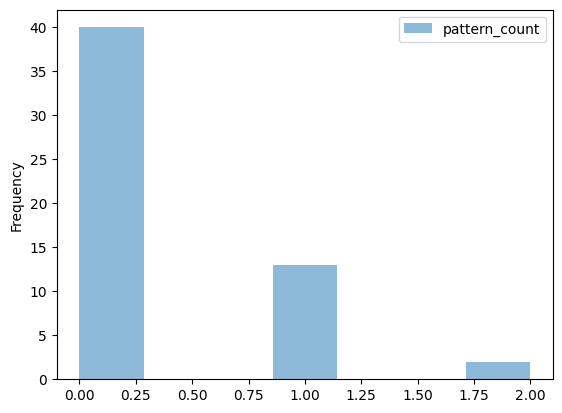

In [48]:
df.plot.hist(y='pattern_count', bins=7, alpha=0.5)

In [49]:
df_2 = df[df['pattern_count'] > 2]
df_2

,id,PC,console,mobile,hours,CS,DOTA,FN,LOL,VAL,noGame,participation,leftGroup,gamerIdentity,revealGender,ingameTeamChatFlame,ingameAllChatFlame,TeamVoiceChatFlame,otherFlame,trollingThrowingSeverity_lastmonth,leavingSeverity_lastmonth,nameCallingSeverity_lastmonth,sexMesSeverity_lastmonth,patronizingSeverity_lastmonth,flirtingSeverity_lastmonth,doxxingSeverity_lastmonth,microAgressionSeverity_lastmonth,noHarassment_lastmonth,typesOther_lastmonth,trollingThrowingSeverity,leavingSeverity,nameCallingSeverity,sexMesSeverity,patronizingSeverity,flirtingSeverity,doxxingSeverity,microAgressionSeverity,userNameChange,voiceSettingsChange,profileInfoChange,noChanges,changeOtherIdentity,senseOfBelonging,discouraging,welcomingSpace,avoidCommunities,affectedIngameComms,affectedJoinComp,affectedNonComp,reportingMe,reportingOther,mutingTeamVoice,mutingTeamText,mutingVoicePlayer,mutingTextPlayer,mutingAllVoice,mutingAllText,upsetsMe,upsetAfterPlaying,teamSupportsMe,notPhased,teamSaysNothing,teamAddsSexism,ex1,ex2,ex3,ex4,ex5,ex6,ex7,ex8,ex9,ex10,exSev1,exSev2,exSev3,exSev4,exSev5,exSev6,exSev7,exSev8,exSev9,exSev10,gender,genderOther,age,EU,ASIA,SA,NA,AFR,ASIA,OCE,diagonal_pattern_flag_exSev,alternating_pattern_flag_exSev,repeating_block_flag_exSev,pattern_response_flag_exSev,straight_line_flag_types,diagonal_pattern_flag_types,alternating_pattern_flag_types,repeating_block_flag_types,pattern_response_flag_types,straight_line_flag_willingness,diagonal_pattern_flag_willingness,alternating_pattern_flag_willingness,repeating_block_flag_willingness,pattern_response_flag_willingness,straight_line_flag_mech,diagonal_pattern_flag_mech,alternating_pattern_flag_mech,repeating_block_flag_mech,pattern_response_flag_mech,straight_line_flag_statement,diagonal_pattern_flag_statement,alternating_pattern_flag_statement,repeating_block_flag_statement,pattern_response_flag_statement,pattern_count


In [50]:
df_2.to_csv('pattern_response_s1.csv', index=False)

In [51]:
df_cleaned = df_cleaned.drop([
       'diagonal_pattern_flag_exSev', 'alternating_pattern_flag_exSev',
       'repeating_block_flag_exSev', 'pattern_response_flag_exSev',
       'straight_line_flag_types', 'diagonal_pattern_flag_types',
       'alternating_pattern_flag_types', 'repeating_block_flag_types',
       'pattern_response_flag_types', 'straight_line_flag_willingness',
       'diagonal_pattern_flag_willingness', 'alternating_pattern_flag_willingness',
       'repeating_block_flag_willingness', 'pattern_response_flag_willingness',
       'straight_line_flag_mech', 'diagonal_pattern_flag_mech',
       'alternating_pattern_flag_mech', 'repeating_block_flag_mech', 'pattern_response_flag_mech', 'straight_line_flag_statement',
       'diagonal_pattern_flag_statement', 'alternating_pattern_flag_statement',
       'repeating_block_flag_statement', 'pattern_response_flag_statement',
 ], axis=1)


df_cleaned.columns

Index(['id', 'PC', 'console', 'mobile', 'hours', 'CS', 'DOTA', 'FN', 'LOL',
       'VAL', 'noGame', 'participation', 'leftGroup', 'gamerIdentity',
       'revealGender', 'ingameTeamChatFlame', 'ingameAllChatFlame',
       'TeamVoiceChatFlame', 'otherFlame',
       'trollingThrowingSeverity_lastmonth', 'leavingSeverity_lastmonth',
       'nameCallingSeverity_lastmonth', 'sexMesSeverity_lastmonth',
       'patronizingSeverity_lastmonth', 'flirtingSeverity_lastmonth',
       'doxxingSeverity_lastmonth', 'microAgressionSeverity_lastmonth',
       'noHarassment_lastmonth', 'typesOther_lastmonth',
       'trollingThrowingSeverity', 'leavingSeverity', 'nameCallingSeverity',
       'sexMesSeverity', 'patronizingSeverity', 'flirtingSeverity',
       'doxxingSeverity', 'microAgressionSeverity', 'userNameChange',
       'voiceSettingsChange', 'profileInfoChange', 'noChanges',
       'changeOtherIdentity', 'senseOfBelonging', 'discouraging',
       'welcomingSpace', 'avoidCommunities', 'affectedIn

In [52]:
df_cleaned.to_csv('all_answers_cleaned_s1.csv', index=False)